# Cross-Pair Statistical Arbitrage Research Notebook

This notebook is designed to produce a **more defensible** pairs-trading project by:

- testing **multiple candidate pairs** instead of relying on a single intuitive pair,
- using a **rolling hedge ratio**,
- evaluating a **simple vs filtered** version of the strategy,
- comparing **out-of-sample** Sharpe / return / drawdown,
- selecting the **best-performing pair/parameter set** on the test period.

It does **not** assume that any single pair must be profitable.  
Instead, it follows a more realistic research process: generate hypotheses, test them, compare them, and report the strongest result.


In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = "{:.4f}".format


## 1) Candidate pairs

In [14]:
# You can add/remove pairs here
candidate_pairs = [
    ("KO", "PEP"),
    ("XOM", "CVX"),
    ("JPM", "BAC"),
    ("V", "MA"),
    ("MCD", "YUM"),
    ("COP", "EOG"),
]
START_DATE = "2015-01-01"
SPLIT_DATE = "2022-01-01"


## 2) Helper functions

In [16]:
def download_pair(a, b, start=START_DATE):
    px = yf.download([a, b], start=start, auto_adjust=True, progress=False)["Close"].dropna()
    # standardize internal names so strategy code stays simple
    px.columns = ["A", "B"]
    return px

def estimate_beta(y, x):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    return float(model.params[1])

def rolling_beta(prices: pd.DataFrame, window: int = 126) -> pd.Series:
    betas = []
    idx = prices.index
    for i in range(window, len(prices)):
        y = prices["A"].iloc[i-window:i]
        x = prices["B"].iloc[i-window:i]
        betas.append(estimate_beta(y, x))
    return pd.Series(betas, index=idx[window:])

def rolling_adf_pvalue(series: pd.Series, window: int = 126) -> pd.Series:
    pvals = []
    idx = series.index
    for i in range(window, len(series)):
        sample = series.iloc[i-window:i].dropna()
        if len(sample) < window:
            pvals.append(np.nan)
        else:
            try:
                pvals.append(adfuller(sample)[1])
            except Exception:
                pvals.append(np.nan)
    return pd.Series(pvals, index=idx[window:])

def perf_stats(r: pd.Series, ann_factor: int = 252) -> dict:
    r = r.dropna()
    if len(r) == 0:
        return {
            "ann_return": np.nan,
            "ann_vol": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "win_rate": np.nan,
            "total_return": np.nan,
            "days": 0,
        }
    mu = r.mean() * ann_factor
    vol = r.std(ddof=0) * np.sqrt(ann_factor)
    sharpe = np.nan if vol == 0 else mu / vol
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    return {
        "ann_return": float(mu),
        "ann_vol": float(vol),
        "sharpe": float(sharpe),
        "max_drawdown": float(dd.min()),
        "win_rate": float((r > 0).mean()),
        "total_return": float(eq.iloc[-1] - 1),
        "days": int(len(r)),
    }


## 3) Strategy functions

In [18]:
def strategy_simple(prices: pd.DataFrame, beta_window=126, z_window=20, cost_bps=7):
    beta = rolling_beta(prices, window=beta_window)
    px = prices.loc[beta.index].copy()
    spread = px["A"] - beta * px["B"]

    z = (spread - spread.rolling(z_window).mean()) / spread.rolling(z_window).std(ddof=0)
    pos = -np.tanh(z).clip(-1, 1)
    pos = pos.fillna(0)

    ret = px.pct_change().dropna()
    spread_ret = ret["A"] - beta.reindex(ret.index) * ret["B"]

    pos = pos.reindex(spread_ret.index).fillna(0)
    gross = pos.shift(1).fillna(0) * spread_ret
    costs = pos.diff().abs().fillna(0) * (cost_bps / 10000)
    net = gross - costs
    return {
        "beta": beta,
        "spread": spread,
        "z": z,
        "position": pos,
        "returns": net,
    }

def strategy_filtered(prices: pd.DataFrame, beta_window=126, z_window=20, adf_window=126, adf_threshold=0.10, z_cap=3, cost_bps=7):
    beta = rolling_beta(prices, window=beta_window)
    px = prices.loc[beta.index].copy()
    spread = px["A"] - beta * px["B"]

    z = (spread - spread.rolling(z_window).mean()) / spread.rolling(z_window).std(ddof=0)
    adf_p = rolling_adf_pvalue(spread, window=adf_window)
    coint_filter = (adf_p < adf_threshold).reindex(z.index)
    coint_filter = coint_filter.astype("boolean").fillna(False)

    pos = -np.tanh(z)
    pos = pos.where(z.abs() <= z_cap, 0)
    pos = pos.where(coint_filter, 0).fillna(0)

    ret = px.pct_change().dropna()
    spread_ret = ret["A"] - beta.reindex(ret.index) * ret["B"]

    pos = pos.reindex(spread_ret.index).fillna(0)
    gross = pos.shift(1).fillna(0) * spread_ret
    costs = pos.diff().abs().fillna(0) * (cost_bps / 10000)
    net = gross - costs

    return {
        "beta": beta,
        "spread": spread,
        "z": z,
        "adf_p": adf_p,
        "position": pos,
        "returns": net,
    }


## 4) Research loop across pairs and parameters

In [20]:
beta_windows = [63, 126, 252]
z_windows = [20, 40, 60]
models = ["simple", "filtered"]

rows = []
cache = {}

for a, b in candidate_pairs:
    try:
        px = download_pair(a, b)
        train = px.loc[:SPLIT_DATE].copy()
        test = px.loc[SPLIT_DATE:].copy()

        for bw in beta_windows:
            for zw in z_windows:
                for model_name in models:
                    try:
                        if model_name == "simple":
                            train_res = strategy_simple(train, beta_window=bw, z_window=zw)
                            test_res = strategy_simple(test, beta_window=bw, z_window=zw)
                        else:
                            train_res = strategy_filtered(train, beta_window=bw, z_window=zw, adf_window=bw)
                            test_res = strategy_filtered(test, beta_window=bw, z_window=zw, adf_window=bw)

                        train_stats = perf_stats(train_res["returns"])
                        test_stats = perf_stats(test_res["returns"])

                        key = (a, b, model_name, bw, zw)
                        cache[key] = {"train": train_res, "test": test_res}

                        rows.append({
                            "pair": f"{a}-{b}",
                            "model": model_name,
                            "beta_window": bw,
                            "z_window": zw,
                            "train_sharpe": train_stats["sharpe"],
                            "train_total_return": train_stats["total_return"],
                            "train_mdd": train_stats["max_drawdown"],
                            "test_sharpe": test_stats["sharpe"],
                            "test_total_return": test_stats["total_return"],
                            "test_mdd": test_stats["max_drawdown"],
                            "test_days": test_stats["days"],
                        })
                    except Exception as e:
                        print(f"strategy error {a}-{b}, {model_name}, bw={bw}, zw={zw}: {e}")
    except Exception as e:
        print(f"download error {a}-{b}: {e}")

results = pd.DataFrame(rows)
print("Rows generated:", len(results))
results.head()


Rows generated: 108


,pair,model,beta_window,z_window,train_sharpe,train_total_return,train_mdd,test_sharpe,test_total_return,test_mdd,test_days
0,KO-PEP,simple,63,20,0.1237,0.0529,-0.3648,-0.5656,-0.2347,-0.2909,1002
1,KO-PEP,filtered,63,20,-0.3595,-0.1201,-0.1659,0.2787,0.0449,-0.0546,1002
2,KO-PEP,simple,63,40,0.0057,-0.0416,-0.3334,-0.0626,-0.0466,-0.1569,1002
3,KO-PEP,filtered,63,40,-0.0233,-0.0151,-0.1208,0.2461,0.0361,-0.0538,1002
4,KO-PEP,simple,63,60,-0.2954,-0.2338,-0.3123,0.0320,-0.0065,-0.1687,1002


## 5) Best out-of-sample results

In [22]:
if len(results) == 0:
    raise ValueError("No results were generated. Check downloads or strategy code.")

top_results = results.sort_values(
    ["test_sharpe", "test_total_return"],
    ascending=[False, False]
).reset_index(drop=True)

top_results.head(15)


,pair,model,beta_window,z_window,train_sharpe,train_total_return,train_mdd,test_sharpe,test_total_return,test_mdd,test_days
0,COP-EOG,simple,252,20,-0.2696,-0.3755,-0.5472,0.9731,0.5337,-0.1903,813
1,V-MA,filtered,126,40,0.1028,0.0268,-0.1371,0.7517,0.1036,-0.0287,939
2,COP-EOG,simple,252,40,-0.2572,-0.3753,-0.6374,0.7240,0.3571,-0.2066,813
3,XOM-CVX,filtered,252,20,-0.4377,-0.1471,-0.2203,0.6838,0.0208,-0.0018,813
4,V-MA,filtered,126,20,0.1541,0.0482,-0.1565,0.6749,0.1168,-0.0283,939
5,MCD-YUM,filtered,252,60,0.1206,0.0327,-0.1043,0.6274,0.0038,-0.0006,813
6,V-MA,filtered,63,60,-0.2787,-0.0880,-0.1484,0.6194,0.1201,-0.0700,1002
7,V-MA,filtered,63,20,-0.1231,-0.0654,-0.1671,0.6052,0.1562,-0.0792,1002
8,MCD-YUM,filtered,252,40,0.3367,0.1027,-0.0542,0.5695,0.0015,-0.0005,813
9,JPM-BAC,simple,126,60,-0.0240,-0.1639,-0.5000,0.4823,0.3076,-0.3320,939


## 6) Select the best configuration

In [24]:
best = top_results.iloc[0]
best


pair                  COP-EOG
model                  simple
beta_window               252
z_window                   20
train_sharpe          -0.2696
train_total_return    -0.3755
train_mdd             -0.5472
test_sharpe            0.9731
test_total_return      0.5337
test_mdd              -0.1903
test_days                 813
Name: 0, dtype: object

In [26]:
pair_a, pair_b = best["pair"].split("-")
best_key = (pair_a, pair_b, best["model"], int(best["beta_window"]), int(best["z_window"]))
best_train = cache[best_key]["train"]
best_test = cache[best_key]["test"]

print("Selected config:", best_key)
print("\nTrain stats:")
print(perf_stats(best_train["returns"]))
print("\nTest stats:")
print(perf_stats(best_test["returns"]))


Selected config: ('COP', 'EOG', 'simple', 252, 20)

Train stats:
{'ann_return': -0.056475728620768245, 'ann_vol': 0.20945246961933955, 'sharpe': -0.26963505717267333, 'max_drawdown': -0.5472197021073286, 'win_rate': 0.48410596026490066, 'total_return': -0.3754682933699526, 'days': 1510}

Test stats:
{'ann_return': 0.14348818444891145, 'ann_vol': 0.14745166824777273, 'sharpe': 0.973120115587969, 'max_drawdown': -0.19028563862728876, 'win_rate': 0.5092250922509225, 'total_return': 0.5337034550162587, 'days': 813}


## 7) Plot the selected strategy

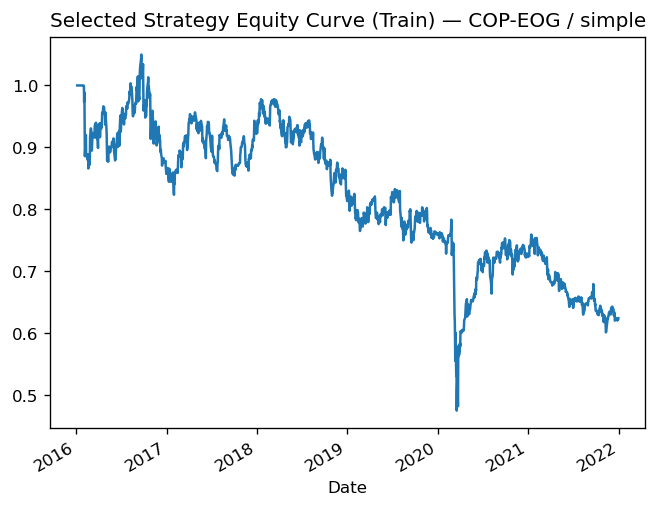

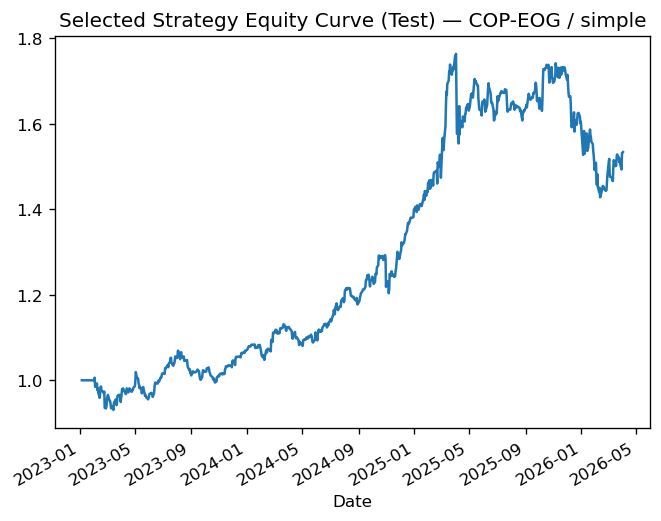

In [28]:
train_eq = (1 + best_train["returns"].fillna(0)).cumprod()
test_eq = (1 + best_test["returns"].fillna(0)).cumprod()

train_eq.plot(title=f"Selected Strategy Equity Curve (Train) — {best['pair']} / {best['model']}")
plt.show()

test_eq.plot(title=f"Selected Strategy Equity Curve (Test) — {best['pair']} / {best['model']}")
plt.show()


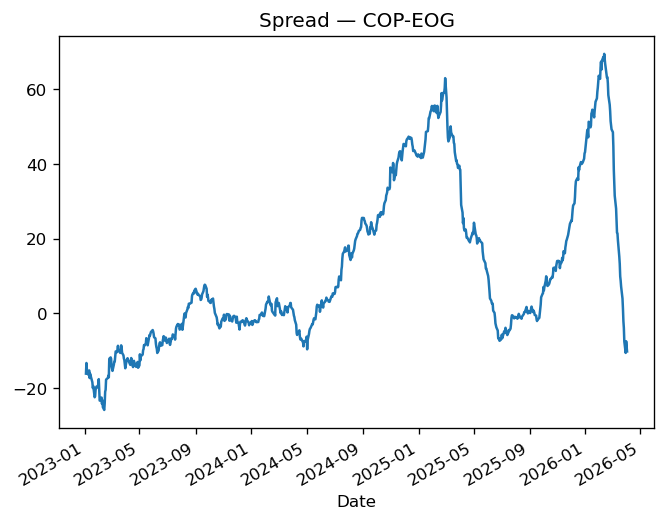

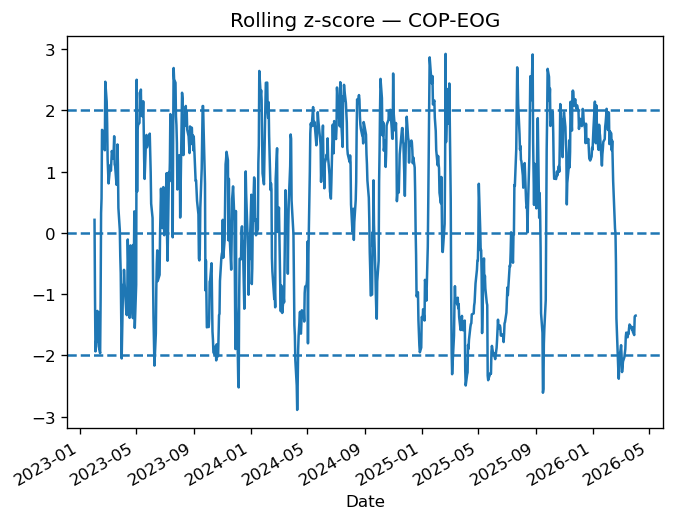

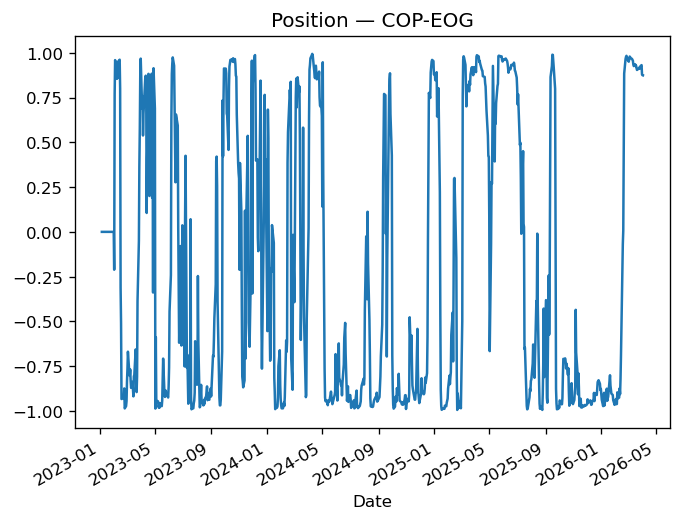

In [30]:
best_test["spread"].plot(title=f"Spread — {best['pair']}")
plt.show()

best_test["z"].plot(title=f"Rolling z-score — {best['pair']}")
plt.axhline(0, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.show()

best_test["position"].plot(title=f"Position — {best['pair']}")
plt.show()


## 8) Final project summary

In [32]:
summary = {
    "Selected Pair": best["pair"],
    "Model": best["model"],
    "Beta Window": int(best["beta_window"]),
    "Z Window": int(best["z_window"]),
    "Test Sharpe": round(float(best["test_sharpe"]), 4),
    "Test Total Return": round(float(best["test_total_return"]), 4),
    "Test Max Drawdown": round(float(best["test_mdd"]), 4),
}
summary


{'Selected Pair': 'COP-EOG',
 'Model': 'simple',
 'Beta Window': 252,
 'Z Window': 20,
 'Test Sharpe': 0.9731,
 'Test Total Return': 0.5337,
 'Test Max Drawdown': -0.1903}